# EDA — Definición del Problema

Este notebook realiza un análisis exploratorio de datos sobre la tabla analítica primaria validada:

**Dataset:** `retail_daily_primary`  
**Grano:** `fecha × store_id × categoría`  
**Ubicación:** `data/03_primary/retail_daily_primary.parquet`

El dataset fue generado por el pipeline `primary`, que integró:
- `transactions_clean` — tabla de hechos (ventas diarias por tienda y categoría)
- `stores_clean` — características de tienda (formato, región, NSE, etc.)
- `calendar_clean` — variables temporales y eventos del retail mexicano

**Objetivo:** Este EDA apoya la definición del problema. El objetivo no es solo la exploración, sino identificar variables objetivo y variables explicativas prometedoras, y determinar si el pronóstico de demanda al nivel `fecha × store_id × categoría` es una formulación de problema defendible.

## 1. Carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_parquet("../data/03_primary/retail_daily_primary.parquet")
print(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Cargado: 203,958 filas × 36 columnas


## 2. Resumen general

In [2]:
print("Dimensiones:", df.shape)
print("\nRango de fechas:", df["date_dt"].min().date(), "→", df["date_dt"].max().date())
print("Días en el dataset:", df["date_dt"].nunique())
print("Tiendas:", df["store_id"].nunique())
print("Categorías:", df["category"].nunique(), "→", sorted(df["category"].unique()))
print("Regiones:", df["region"].nunique(), "→", sorted(df["region"].unique()))
print("Formatos de tienda:", df["store_format"].nunique(), "→", sorted(df["store_format"].unique()))

Dimensiones: (203958, 36)

Rango de fechas: 2023-01-01 → 2024-02-29
Días en el dataset: 425
Tiendas: 80
Categorías: 6 → ['Abarrotes', 'Bebidas', 'Cuidado_Personal', 'Electronica', 'Hogar', 'Ropa']
Regiones: 5 → ['Centro', 'Norte', 'Occidente', 'Oriente', 'Sur']
Formatos de tienda: 3 → ['Bodega', 'Express', 'Supercenter']


In [3]:
df.dtypes

date                            string
store_id                        string
category                        string
total_transactions               int64
cash_transactions                Int64
card_transactions                int64
amount_total                   float64
amount_cash                    Float64
amount_card                    float64
units_sold                     Float64
avg_ticket                     Float64
has_promotion                    int64
replenishment_signal           Float64
store_format                    string
region                          string
size_sqm                         int64
num_checkouts                    int64
opening_year                     int64
socioeconomic_level             string
has_pharmacy                      bool
has_fuel_station                  bool
day_of_week                      int64
day_name                        string
week_of_year                     int64
month                            int64
year                     

In [4]:
df.head(3)

,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,...,quarter,season,is_holiday,holiday_name,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa,date_dt
0,2023-01-01,STR_001,Abarrotes,833,<NA>,326,244732.98,<NA>,101822.79,2299.0,...,1,Invierno,True,Año Nuevo,False,True,True,False,False,2023-01-01
1,2023-01-01,STR_001,Bebidas,731,325,406,114173.75,50105.4,64068.35,1961.0,...,1,Invierno,True,Año Nuevo,False,True,True,False,False,2023-01-01
2,2023-01-01,STR_001,Cuidado_Personal,577,255,322,114885.57,51049.8,63835.77,751.0,...,1,Invierno,True,Año Nuevo,False,True,True,False,False,2023-01-01


## 3. Validación de granularidad

La capa primaria preserva la granularidad transaccional de `transactions_clean`. Cada fila representa una combinación de (fecha, store_id, categoría). Verificamos que no existan duplicados para esa llave.

In [5]:
PRIMARY_KEY = ["date", "store_id", "category"]
n_dupes = df.duplicated(subset=PRIMARY_KEY).sum()
print(f"Filas duplicadas por {PRIMARY_KEY}: {n_dupes}")
print("Validación de granularidad:", "APROBADA" if n_dupes == 0 else "FALLIDA")

Filas duplicadas por ['date', 'store_id', 'category']: 0
Validación de granularidad: APROBADA


## 4. Calidad de datos — valores faltantes

In [6]:
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2)
}).query("null_count > 0").sort_values("null_pct", ascending=False)

print(null_summary.to_string())

                      null_count  null_pct
holiday_name              195318     95.76
cash_transactions          12123      5.94
amount_cash                12123      5.94
units_sold                  6118      3.00
avg_ticket                  4874      2.39
replenishment_signal         960      0.47


In [7]:
focus_cols = ["cash_transactions", "amount_cash", "units_sold", "avg_ticket", "replenishment_signal", "holiday_name"]

# Nulls by store
nulls_by_store = df.groupby("store_id")[focus_cols].apply(lambda x: x.isnull().mean() * 100).round(1)
print("% de nulos por tienda (columnas de interés):")
print(nulls_by_store.describe().round(1))

% de nulos por tienda (columnas de interés):
       cash_transactions  amount_cash  units_sold  avg_ticket  \
count               80.0         80.0        80.0        80.0   
mean                 5.9          5.9         3.0         2.4   
std                  0.5          0.5         0.3         0.3   
min                  4.9          4.9         2.2         1.4   
25%                  5.5          5.5         2.8         2.2   
50%                  6.0          6.0         3.0         2.4   
75%                  6.3          6.3         3.1         2.6   
max                  7.0          7.0         3.8         3.1   

       replenishment_signal  holiday_name  
count                  80.0          80.0  
mean                    0.5          95.8  
std                     0.0           0.0  
min                     0.5          95.7  
25%                     0.5          95.8  
50%                     0.5          95.8  
75%                     0.5          95.8  
max              

In [8]:
# Nulls by category
nulls_by_cat = df.groupby("category")[focus_cols].apply(lambda x: x.isnull().mean() * 100).round(1)
print("% de nulos por categoría (columnas de interés):")
print(nulls_by_cat)

% de nulos por categoría (columnas de interés):
                  cash_transactions  amount_cash  units_sold  avg_ticket  \
category                                                                   
Abarrotes                       6.0          6.0         3.0         2.4   
Bebidas                         5.8          5.8         3.0         2.4   
Cuidado_Personal                5.8          5.8         2.9         2.3   
Electronica                     6.1          6.1         3.1         2.5   
Hogar                           5.9          5.9         3.0         2.3   
Ropa                            6.0          6.0         3.0         2.4   

                  replenishment_signal  holiday_name  
category                                              
Abarrotes                          0.5          95.8  
Bebidas                            0.5          95.8  
Cuidado_Personal                   0.5          95.8  
Electronica                        0.5          95.8  
Hogar        

In [9]:
# Nulls over time (monthly)
monthly_nulls = (
    df.assign(month=df["date_dt"].dt.to_period("M"))
    .groupby("month")[focus_cols]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
)
print("% de nulos por mes (columnas de interés):")
print(monthly_nulls)

% de nulos por mes (columnas de interés):
         cash_transactions  amount_cash  units_sold  avg_ticket  \
month                                                             
2023-01                6.0          6.0         3.1         2.3   
2023-02                5.9          5.9         3.1         2.4   
2023-03                5.8          5.8         3.0         2.4   
2023-04                5.6          5.6         3.1         2.3   
2023-05                6.4          6.4         2.7         2.3   
2023-06                6.0          6.0         3.0         2.3   
2023-07                5.9          5.9         3.2         2.4   
2023-08                5.8          5.8         2.9         2.5   
2023-09                6.1          6.1         3.1         2.5   
2023-10                5.6          5.6         2.8         2.2   
2023-11                6.0          6.0         2.9         2.5   
2023-12                6.4          6.4         3.0         2.5   
2024-01             

## 5. Verificación de consistencia en transacciones

Verificamos si `total_transactions = cash_transactions + card_transactions`. Dado que `cash_transactions` puede ser nulo, solo evaluamos las filas donde este campo está disponible.

In [10]:
checkable = df[df["cash_transactions"].notna()].copy()
checkable["sum_check"] = checkable["cash_transactions"] + checkable["card_transactions"]
checkable["inconsistent"] = ~np.isclose(checkable["total_transactions"], checkable["sum_check"], rtol=1e-5)

n_inconsistent = checkable["inconsistent"].sum()
pct_inconsistent = n_inconsistent / len(checkable) * 100

print(f"Filas evaluadas: {len(checkable):,}")
print(f"Filas inconsistentes: {n_inconsistent:,} ({pct_inconsistent:.2f}%)")

if n_inconsistent > 0:
    print("\nMuestra de filas inconsistentes:")
    display(checkable[checkable["inconsistent"]][["date", "store_id", "category", "total_transactions", "cash_transactions", "card_transactions", "sum_check"]].head(5))
else:
    print("No se encontraron inconsistencias — el desglose de transacciones es internamente consistente donde existen datos de efectivo.")

Filas evaluadas: 191,835
Filas inconsistentes: 38,295 (19.96%)

Muestra de filas inconsistentes:


,date,store_id,category,total_transactions,cash_transactions,card_transactions,sum_check
5,2023-01-01,STR_001,Ropa,313,97,160,257
15,2023-01-01,STR_003,Electronica,214,45,135,180
16,2023-01-01,STR_003,Hogar,347,111,175,286
54,2023-01-01,STR_010,Abarrotes,832,364,310,674
55,2023-01-01,STR_010,Bebidas,444,187,209,396


## 6. Tiendas con periodos extendidos de datos faltantes

In [11]:
total_days = df["date_dt"].nunique()
n_categories = df["category"].nunique()
expected_records = total_days * n_categories

store_coverage = (
    df.groupby("store_id")
    .agg(
        records=("date", "count"),
        active_dates=("date", "nunique"),
    )
    .assign(expected_records=expected_records)
    .assign(coverage_pct=lambda x: (x["records"] / x["expected_records"] * 100).round(1))
    .sort_values("coverage_pct")
)

print(f"Registros esperados por tienda: {expected_records:,} ({total_days} días × {n_categories} categorías)")
print(f"\nTiendas con < 80% de cobertura:")
print(store_coverage[store_coverage["coverage_pct"] < 80].to_string())
print(f"\nResumen de cobertura:")
print(store_coverage["coverage_pct"].describe().round(1))

Registros esperados por tienda: 2,550 (425 días × 6 categorías)

Tiendas con < 80% de cobertura:
Empty DataFrame
Columns: [records, active_dates, expected_records, coverage_pct]
Index: []

Resumen de cobertura:
count     80.0
mean     100.0
std        0.1
min       99.3
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: coverage_pct, dtype: float64


**Conclusión de cobertura:** La llave `date × store_id × category` no presenta duplicados. La cobertura es prácticamente completa: se observan 203,958 combinaciones frente a 204,000 esperadas (425 días × 80 tiendas × 6 categorías), lo que representa 42 combinaciones fecha-tienda-categoría faltantes. Esta magnitud es pequeña y no impide plantear una primera solución de pronóstico, aunque debe documentarse como una limitación menor de cobertura.

## 7. Análisis de variables objetivo candidatas

In [12]:
targets = ["amount_total", "units_sold", "total_transactions", "avg_ticket", "replenishment_signal"]

target_summary = pd.DataFrame({
    "missing_pct": (df[targets].isnull().mean() * 100).round(2),
    "mean": df[targets].mean().round(2),
    "std": df[targets].std().round(2),
    "min": df[targets].min().round(2),
    "p25": df[targets].quantile(0.25).round(2),
    "median": df[targets].median().round(2),
    "p75": df[targets].quantile(0.75).round(2),
    "max": df[targets].max().round(2),
})
print(target_summary.to_string())

                      missing_pct       mean        std      min       p25     median        p75         max
amount_total                 0.00  170581.26  150445.65  6922.32  78798.17  129965.23  213323.91  4050995.63
units_sold                   3.00    1175.41    1264.96     22.0     418.0      793.0     1487.0     31936.0
total_transactions           0.00     613.51     631.77     14.0     228.0      424.0      783.0     15194.0
avg_ticket                   2.39     411.76     303.64    69.86    182.44     297.03     534.14     1931.74
replenishment_signal         0.47     614.45      538.1    34.67    249.86     447.57     809.57      7064.0


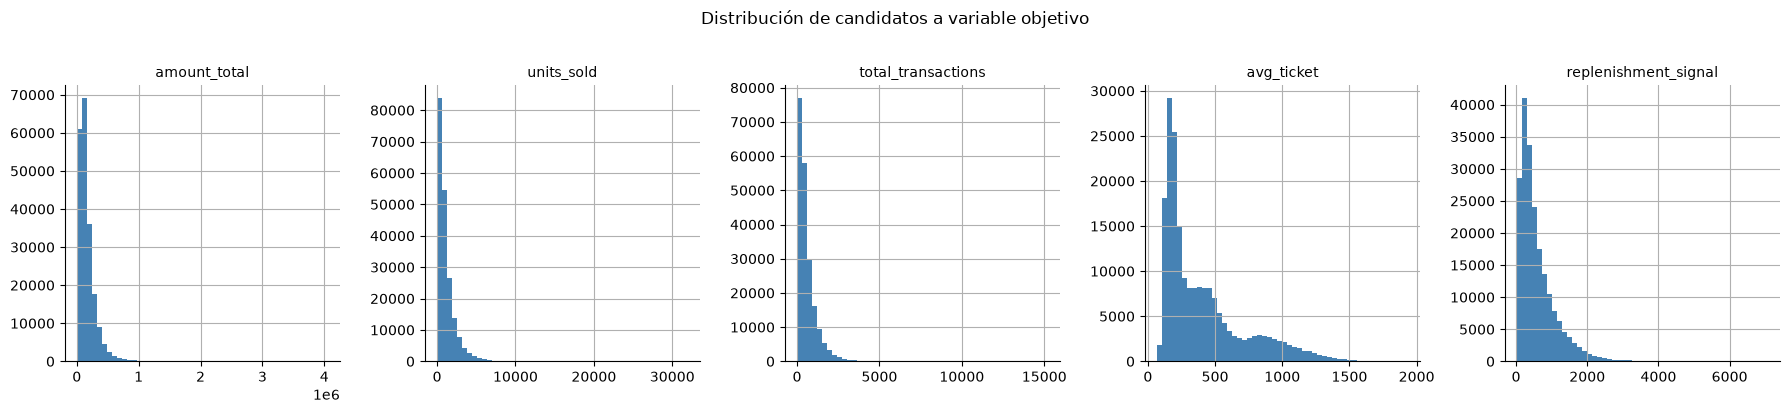

In [13]:
fig, axes = plt.subplots(1, len(targets), figsize=(18, 4))
for ax, col in zip(axes, targets):
    df[col].dropna().hist(bins=50, ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribución de candidatos a variable objetivo", y=1.02)
plt.tight_layout()
plt.show()

**Comparación de variables objetivo candidatas:**

| Variable | Notas |
|---|---|
| `amount_total` | Sin valores faltantes, relevante para el negocio (ingresos), distribución con sesgo positivo — candidato principal |
| `units_sold` | Algunos valores faltantes (3%), directamente relacionado con la demanda, interpretable — buen candidato secundario |
| `total_transactions` | Sin valores faltantes, pero menos directamente ligado al valor económico |
| `avg_ticket` | Métrica derivada (~411 MXN prácticamente constante en todos los eventos temporales); las diferencias observadas son principalmente de volumen de transacciones. Existen diferencias de ticket entre segmentos de tienda (Supercenter ~418 MXN vs Express ~416 MXN) y NSE (A/B ~579 MXN vs C ~340 MXN), aunque no son el factor temporal principal |
| `replenishment_signal` | Generada internamente a partir de la demanda observada — útil para priorización operativa, pero puede introducir fuga de información (leakage) en un modelo de pronóstico de demanda |

> **Nota sobre `replenishment_signal`:** Esta columna es generada internamente con base en la demanda observada. No debe usarse como predictor directo en un modelo de pronóstico de demanda (riesgo de fuga de información). Puede ser más adecuada como variable objetivo de un problema de priorización de reabastecimiento.

## 8. Ventas en el tiempo

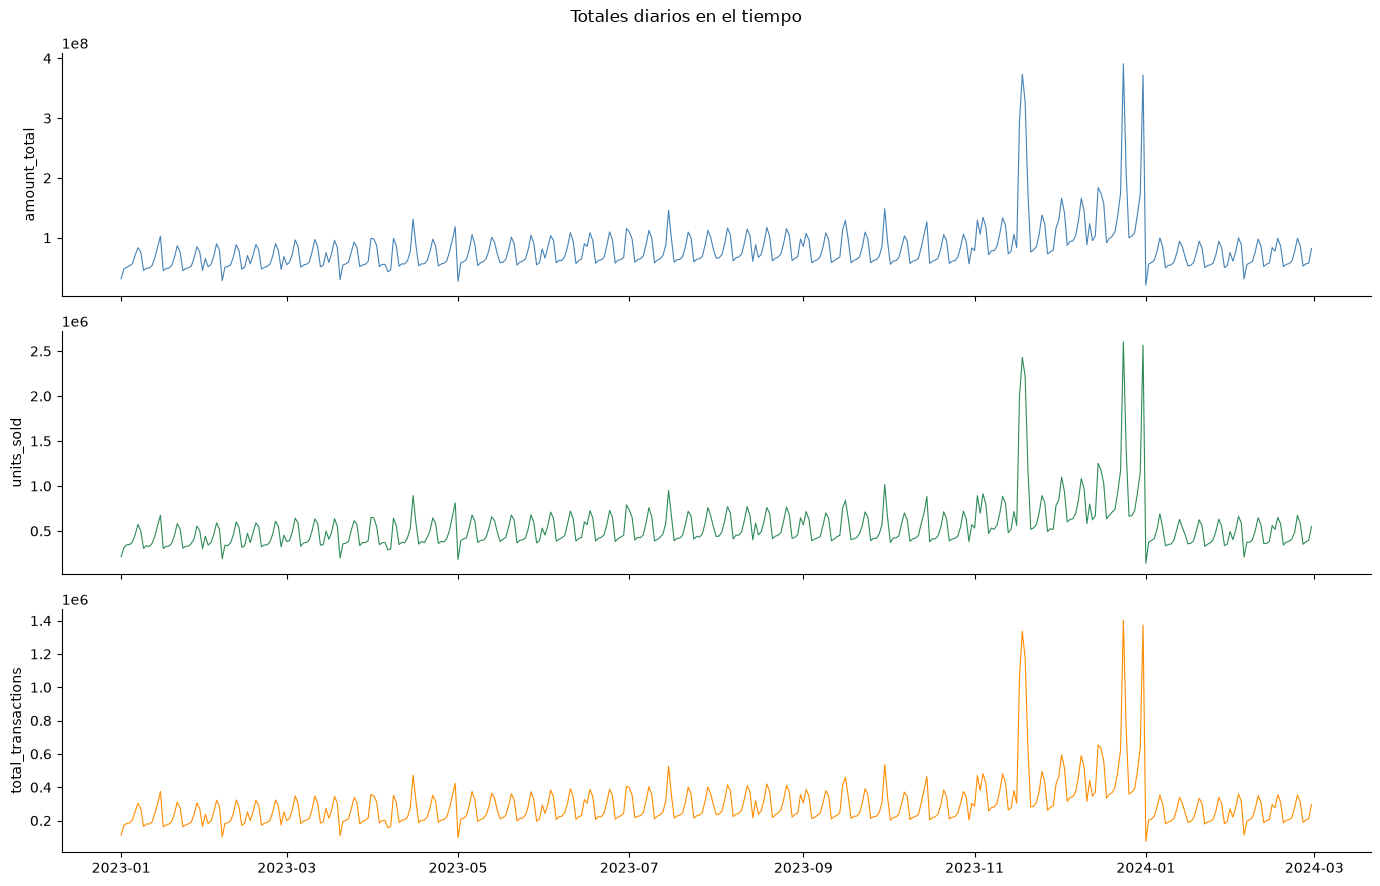

In [14]:
daily = df.groupby("date_dt")[["amount_total", "units_sold", "total_transactions"]].sum()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col, color in zip(axes, ["amount_total", "units_sold", "total_transactions"], ["steelblue", "seagreen", "darkorange"]):
    ax.plot(daily.index, daily[col], lw=0.8, color=color)
    ax.set_ylabel(col)
plt.suptitle("Totales diarios en el tiempo")
plt.tight_layout()
plt.show()

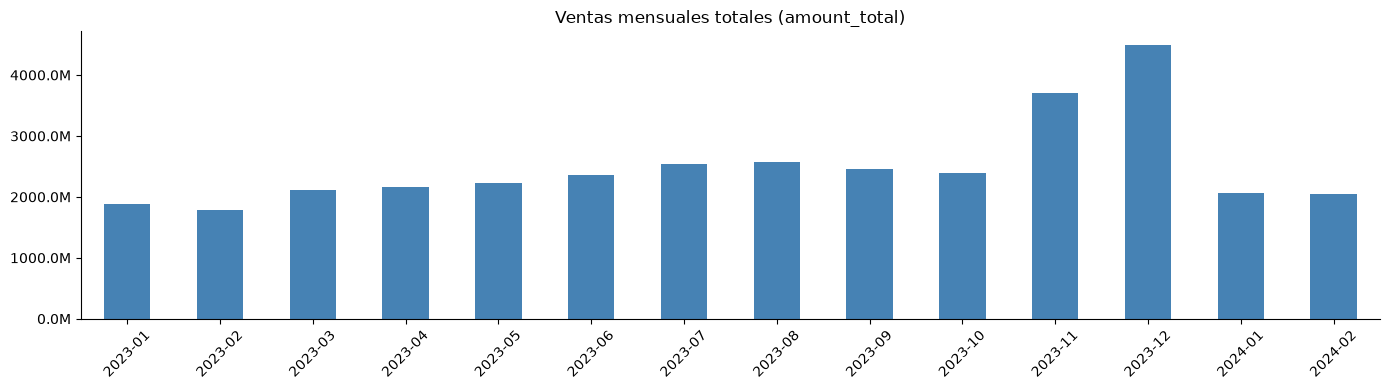

In [15]:
# Monthly trend
monthly = df.assign(month=df["date_dt"].dt.to_period("M")).groupby("month")["amount_total"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
ax.set_title("Ventas mensuales totales (amount_total)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

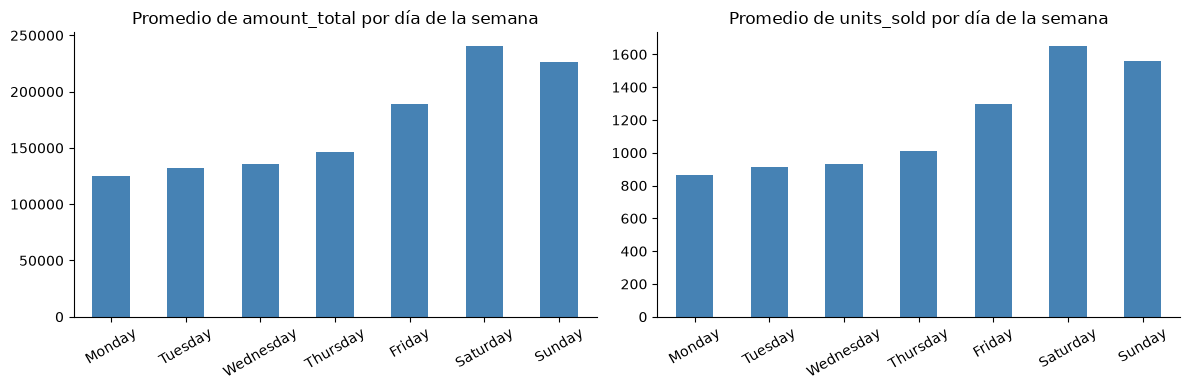

In [16]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = df.groupby("day_name")[["amount_total", "units_sold"]].mean().reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["amount_total", "units_sold"]):
    weekday[col].plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"Promedio de {col} por día de la semana")
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

## 9. Análisis de eventos del retail mexicano

> **Nota:** Las comparaciones siguientes son observacionales. Las diferencias asociadas a estas variables no son causales — pueden estar confundidas por el día de la semana, la mezcla de tiendas, la categoría u otros factores.

In [17]:
event_flags = ["is_payday", "is_holiday", "is_buen_fin", "is_navidad_season", "is_semana_santa", "is_weekend"]
metrics = ["amount_total", "units_sold", "total_transactions", "avg_ticket"]

event_summary = []
for flag in event_flags:
    for val in [True, False]:
        subset = df[df[flag] == val]
        row = {"flag": flag, "value": val, "n": len(subset)}
        for m in metrics:
            row[m] = subset[m].mean()
        event_summary.append(row)

event_df = pd.DataFrame(event_summary)
print(event_df.set_index(["flag", "value"]).round(2).to_string())

                              n  amount_total  units_sold  total_transactions  avg_ticket
flag              value                                                                  
is_payday         True    13440     227860.67     1583.63              823.56      411.60
                  False  190518     166540.51     1146.62              598.70      411.78
is_holiday        True     8640     322065.87     2228.21             1160.26      411.38
                  False  195318     163880.25     1128.88              589.33      411.78
is_buen_fin       True     1920     610249.10     4198.00             2188.19      411.72
                  False  202038     166403.02     1146.63              598.55      411.76
is_navidad_season True    13920     252231.80     1749.86              909.16      411.47
                  False  190038     164600.48     1133.37              591.86      411.79
is_semana_santa   True      960      92885.76      636.29              333.64      411.90
          

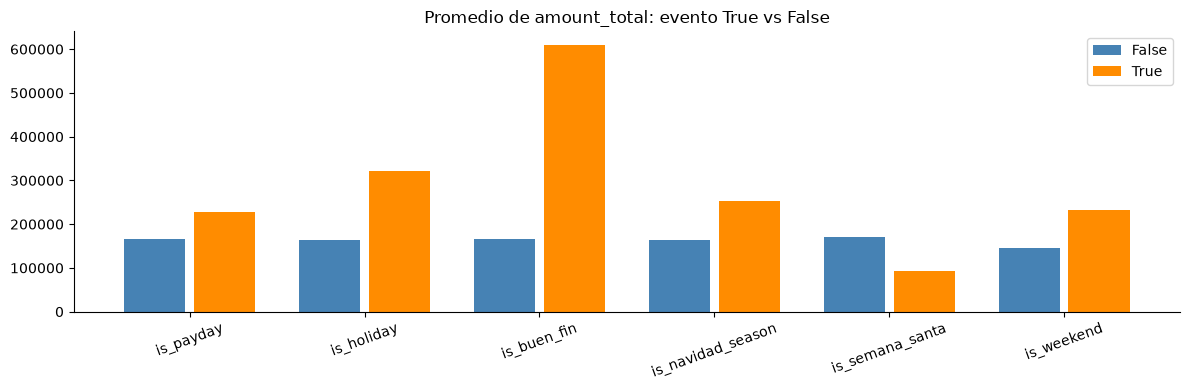

In [18]:
# Visual: mean amount_total by event flag
fig, ax = plt.subplots(figsize=(12, 4))
true_vals = event_df[event_df["value"] == True].set_index("flag")["amount_total"]
false_vals = event_df[event_df["value"] == False].set_index("flag")["amount_total"]
x = range(len(event_flags))
ax.bar([i - 0.2 for i in x], false_vals.values, width=0.35, label="False", color="steelblue")
ax.bar([i + 0.2 for i in x], true_vals.values, width=0.35, label="True", color="darkorange")
ax.set_xticks(list(x))
ax.set_xticklabels(event_flags, rotation=20)
ax.set_title("Promedio de amount_total: evento True vs False")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Análisis de segmentación

In [19]:
# Sales by category
cat_sales = df.groupby("category")[["amount_total", "units_sold", "total_transactions"]].mean().sort_values("amount_total", ascending=False)
print("Métricas promedio por categoría:")
print(cat_sales.round(2).to_string())

Métricas promedio por categoría:
                  amount_total  units_sold  total_transactions
category                                                      
Abarrotes            257363.30     2271.55             1184.14
Electronica          185221.61      377.96              197.39
Hogar                172424.50      877.65              459.60
Ropa                 168685.79      628.67              328.50
Bebidas              131808.46     1764.95              920.03
Cuidado_Personal     107983.89     1131.26              591.41


In [20]:
# Sales by store format
format_sales = df.groupby("store_format")[["amount_total", "units_sold", "avg_ticket"]].mean().sort_values("amount_total", ascending=False)
print("Métricas promedio por formato de tienda:")
print(format_sales.round(2).to_string())

Métricas promedio por formato de tienda:
              amount_total  units_sold  avg_ticket
store_format                                      
Supercenter      283226.71     1919.64      418.03
Bodega           170033.81     1186.85      405.41
Express           81214.24       564.9      415.65


In [21]:
# Sales by region
region_sales = df.groupby("region")[["amount_total", "units_sold"]].mean().sort_values("amount_total", ascending=False)
print("Métricas promedio por región:")
print(region_sales.round(2).to_string())

Métricas promedio por región:
           amount_total  units_sold
region                             
Sur           181357.02     1158.86
Occidente     174925.63     1192.08
Norte         173336.17     1224.36
Centro        172302.90     1229.62
Oriente       154226.41     1086.53


In [22]:
# Sales by socioeconomic level
nse_sales = df.groupby("socioeconomic_level")[["amount_total", "avg_ticket"]].mean().sort_values("amount_total", ascending=False)
print("Métricas promedio por NSE:")
print(nse_sales.round(2).to_string())

Métricas promedio por NSE:
                     amount_total  avg_ticket
socioeconomic_level                          
A/B                     247322.32      578.85
B                       199214.19      479.78
C+                      166086.85      399.66
C                       138590.14      339.97


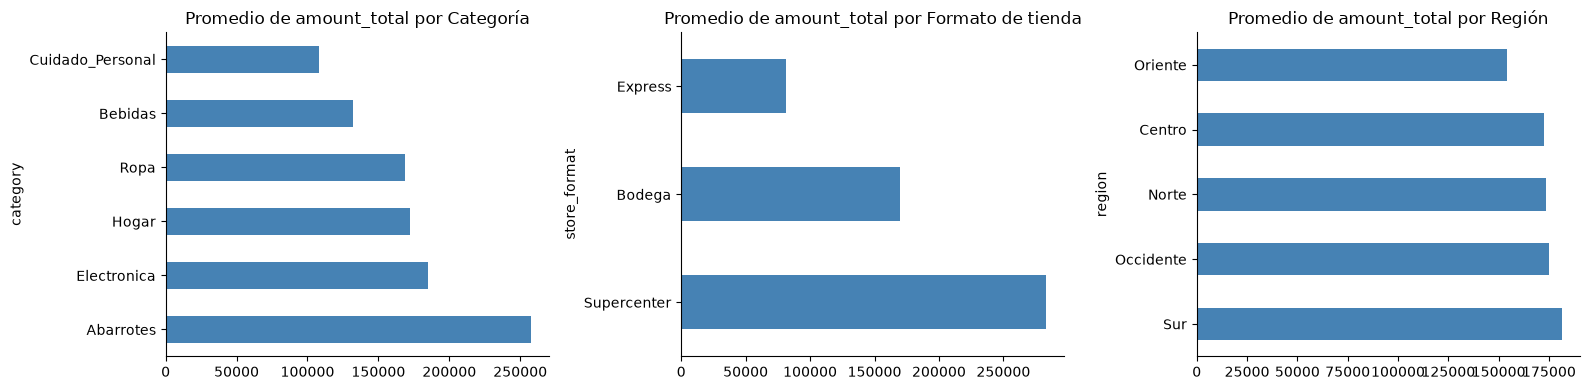

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label in zip(axes, [cat_sales, format_sales, region_sales], ["Categoría", "Formato de tienda", "Región"]):
    col["amount_total"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"Promedio de amount_total por {label}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 11. Análisis de promociones

> **Nota:** Las asociaciones a continuación son observacionales y pueden estar confundidas por categoría, estacionalidad, tipo de tienda o planificación de campañas. No es posible inferir causalidad.

In [24]:
# Overall promoted vs non-promoted
promo_overall = df.groupby("has_promotion")[metrics].mean().round(2)
print("Métricas promedio — con y sin promoción (total):")
print(promo_overall.to_string())

Métricas promedio — con y sin promoción (total):
               amount_total  units_sold  total_transactions  avg_ticket
has_promotion                                                          
0                 170566.53     1174.58              587.12      411.94
1                 170640.26     1178.76              719.22      411.05


In [25]:
# By category
promo_by_cat = df.groupby(["category", "has_promotion"])["amount_total"].mean().unstack().round(2)
promo_by_cat.columns = ["sin_promocion", "con_promocion"]
promo_by_cat["variacion_pct"] = ((promo_by_cat["con_promocion"] / promo_by_cat["sin_promocion"] - 1) * 100).round(1)
print("Promedio de amount_total por categoría y promoción:")
print(promo_by_cat.to_string())

Promedio de amount_total por categoría y promoción:
                  sin_promocion  con_promocion  variacion_pct
category                                                     
Abarrotes             257439.68      257055.48           -0.1
Bebidas               131660.31      132402.35            0.6
Cuidado_Personal      108095.67      107535.29           -0.5
Electronica           184943.75      186335.43            0.8
Hogar                 172314.95      172857.56            0.3
Ropa                  168872.00      167936.90           -0.6


## 12. Análisis de la señal de reabastecimiento

In [26]:
null_rate = df["replenishment_signal"].isnull().mean() * 100
print(f"Tasa de nulos en replenishment_signal: {null_rate:.2f}%")
print(df["replenishment_signal"].describe().round(3))

Tasa de nulos en replenishment_signal: 0.47%
count    202998.0
mean      614.453
std         538.1
min         34.67
25%        249.86
50%        447.57
75%        809.57
max        7064.0
Name: replenishment_signal, dtype: Float64


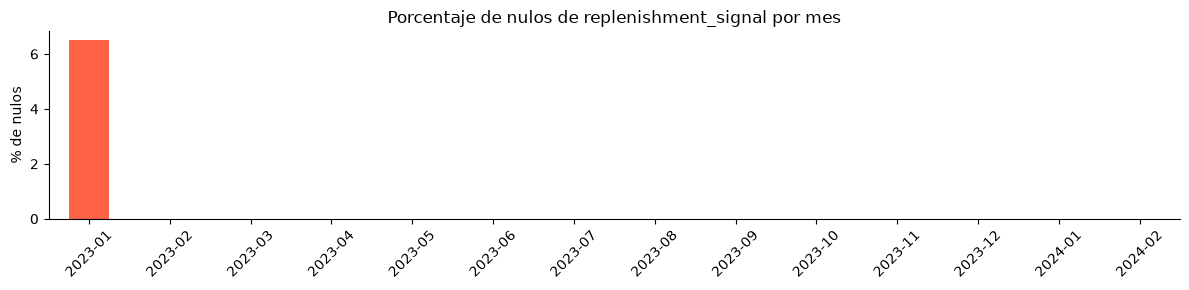

In [27]:
# Null pattern over time (monthly)
monthly_null_repl = (
    df.assign(month=df["date_dt"].dt.to_period("M"))
    .groupby("month")["replenishment_signal"]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(12, 3))
monthly_null_repl.plot(kind="bar", ax=ax, color="tomato", edgecolor="none")
ax.set_title("Porcentaje de nulos de replenishment_signal por mes")
ax.set_xlabel("")
ax.set_ylabel("% de nulos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Correlation with demand variables
repl_valid = df[["replenishment_signal", "units_sold", "amount_total", "total_transactions"]].dropna()
print("Correlaciones con replenishment_signal:")
print(repl_valid.corr()["replenishment_signal"].round(3))

Correlaciones con replenishment_signal:
replenishment_signal    1.000
units_sold              0.814
amount_total            0.558
total_transactions      0.851
Name: replenishment_signal, dtype: float64


In [29]:
# By category and format
print("Promedio de replenishment_signal por categoría:")
print(df.groupby("category")["replenishment_signal"].mean().round(3).sort_values(ascending=False))
print("\nPromedio de replenishment_signal por formato de tienda:")
print(df.groupby("store_format")["replenishment_signal"].mean().round(3).sort_values(ascending=False))

Promedio de replenishment_signal por categoría:
category
Abarrotes           1185.989
Bebidas              921.438
Cuidado_Personal     592.281
Hogar                460.289
Ropa                  329.01
Electronica          197.708
Name: replenishment_signal, dtype: Float64

Promedio de replenishment_signal por formato de tienda:
store_format
Supercenter    1001.881
Bodega          620.909
Express         295.414
Name: replenishment_signal, dtype: Float64


> **Importante:** `replenishment_signal` presenta una asociación alta con variables de demanda observada (correlación con `total_transactions` = 0.851, con `units_sold` = 0.814), por lo que puede ser útil para entender presión operativa o para formular un problema alternativo de priorización. Sin embargo, dado que fue generada internamente con base en demanda observada, no debe usarse de forma ingenua como predictor directo en un modelo de pronóstico de demanda, porque podría introducir fuga de información (leakage).
>
> **Nota sobre los nulos:** Aunque el diccionario de datos menciona que `replenishment_signal` puede contener nulos en los últimos días del periodo, en este dataset concreto los nulos observados se concentran al inicio, específicamente en los dos primeros días del periodo (1 y 2 de enero de 2023). Esto sugiere que la variable puede requerir cuidado al construir rezagos o ventanas históricas, pero no presenta un problema de disponibilidad al final del periodo.

## 13. Validación adicional de viabilidad para pronóstico

Antes de avanzar a la definición formal del problema y al feature engineering, se presentan tres análisis exploratorios para confirmar que el pronóstico de demanda a nivel `date × store_id × category` es viable y evaluable con los datos disponibles.

### 1. Variabilidad por serie tienda-categoría

Total de series (store_id × category): 480

Resumen del coeficiente de variación:
count    480.000
mean       0.523
std        0.035
min        0.441
25%        0.497
50%        0.521
75%        0.544
max        0.641
Name: coeficiente_variacion, dtype: float64

Series de menor variabilidad (CV más bajo):
store_id    category     media  coeficiente_variacion
 STR_080 Electronica 84537.661                  0.441
 STR_071       Hogar 83889.712                  0.441
 STR_074 Electronica 86172.980                  0.450
 STR_074     Bebidas 61374.977                  0.450
 STR_074       Hogar 81155.538                  0.453

Series de mayor variabilidad (CV más alto):
store_id         category      media  coeficiente_variacion
 STR_018             Ropa 283792.324                  0.641
 STR_018          Bebidas 222947.780                  0.634
 STR_016            Hogar 221060.462                  0.633
 STR_004 Cuidado_Personal 186882.261                  0.631
 STR_005 Cuidado_Persona

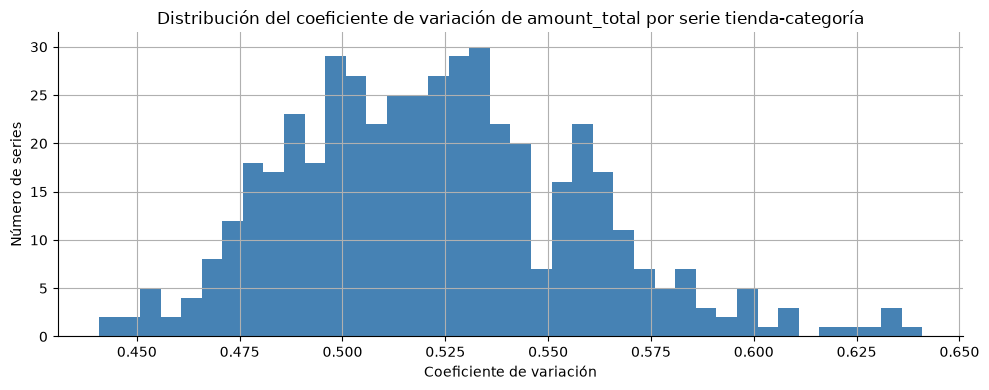

In [30]:
series_stats = (
    df.groupby(["store_id", "category"])["amount_total"]
    .agg(
        n_observaciones="count",
        media="mean",
        desviacion_estandar="std",
        minimo="min",
        maximo="max",
    )
    .reset_index()
)
series_stats["coeficiente_variacion"] = (
    series_stats["desviacion_estandar"] / series_stats["media"]
).where(series_stats["media"] > 0)

print(f"Total de series (store_id × category): {len(series_stats)}")
print("\nResumen del coeficiente de variación:")
print(series_stats["coeficiente_variacion"].describe().round(3))

print("\nSeries de menor variabilidad (CV más bajo):")
print(series_stats.nsmallest(5, "coeficiente_variacion")[
    ["store_id", "category", "media", "coeficiente_variacion"]
].round(3).to_string(index=False))

print("\nSeries de mayor variabilidad (CV más alto):")
print(series_stats.nlargest(5, "coeficiente_variacion")[
    ["store_id", "category", "media", "coeficiente_variacion"]
].round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
series_stats["coeficiente_variacion"].dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="none")
ax.set_title("Distribución del coeficiente de variación de amount_total por serie tienda-categoría")
ax.set_xlabel("Coeficiente de variación")
ax.set_ylabel("Número de series")
plt.tight_layout()
plt.show()

La distribución del coeficiente de variación muestra heterogeneidad entre las distintas combinaciones tienda-categoría: algunas series presentan variabilidad relativa moderada y otras son considerablemente más volátiles. Esto sugiere que no todas las series tendrán el mismo nivel de predictibilidad.

Un modelo global que incorpore variables de calendario, atributos de tienda y categoría puede aprovechar la información compartida entre series — de modo que las combinaciones con menor historia o mayor volatilidad se beneficien de patrones observados en otras. Esta heterogeneidad no invalida el problema de pronóstico, sino que refuerza la necesidad de incluir variables explicativas de contexto.

### 2. Baseline naive preliminar con rezago de 7 días

In [31]:
df_lag = df[["store_id", "category", "date_dt", "amount_total"]].copy()
df_lag = df_lag.sort_values(["store_id", "category", "date_dt"])
df_lag["amount_total_lag_7"] = (
    df_lag.groupby(["store_id", "category"])["amount_total"].shift(7)
)

df_eval = df_lag.dropna(subset=["amount_total_lag_7"]).copy()

mae = (df_eval["amount_total"] - df_eval["amount_total_lag_7"]).abs().mean()
rmse = np.sqrt(((df_eval["amount_total"] - df_eval["amount_total_lag_7"]) ** 2).mean())
smape = (
    2 * (df_eval["amount_total"] - df_eval["amount_total_lag_7"]).abs()
    / (df_eval["amount_total"].abs() + df_eval["amount_total_lag_7"].abs())
).mean() * 100
mae_relativo = mae / df_eval["amount_total"].mean()

print(f"Filas evaluadas: {len(df_eval):,}")
print(f"\nMétricas del baseline naive (lag 7 días):")
print(f"  MAE:           {mae:,.2f}")
print(f"  RMSE:          {rmse:,.2f}")
print(f"  sMAPE:         {smape:.2f}%")
print(f"  MAE relativo:  {mae_relativo:.3f} ({mae_relativo*100:.1f}% del promedio)")

Filas evaluadas: 200,598

Métricas del baseline naive (lag 7 días):
  MAE:           51,586.81
  RMSE:          109,761.30
  sMAPE:         27.28%
  MAE relativo:  0.301 (30.1% del promedio)


El baseline naive con `amount_total_lag_7` usa el valor observado de la misma serie exactamente una semana antes como predicción. Este no es un modelo formal ni una métrica final; su propósito es verificar si existe estructura temporal aprovechable.

Un sMAPE razonable sugiere que la serie tiene memoria temporal y que hay señal explotable con técnicas más sofisticadas. Si el error resultara alto, indicaría que las variables de calendario (quincenas, eventos comerciales, día de semana) y los atributos de tienda y categoría son necesarios para capturar la variación — lo cual es consistente con los hallazgos del EDA.

Este resultado debe interpretarse como evidencia preliminar de viabilidad, no como un benchmark definitivo.

### 3. Estabilidad temporal de amount_total

Resumen mensual de amount_total:
         monto_total_mensual  numero_registros  promedio_diario_mensual  promedio_por_registro
mes                                                                                           
2023-01         1.883669e+09             14880             6.076351e+07              126590.65
2023-02         1.792280e+09             13416             6.401000e+07              133592.73
2023-03         2.117200e+09             14880             6.829677e+07              142284.94
2023-04         2.156066e+09             14400             7.186888e+07              149726.83
2023-05         2.227416e+09             14880             7.185213e+07              149691.94
2023-06         2.362099e+09             14400             7.873663e+07              164034.64
2023-07         2.543082e+09             14880             8.203491e+07              170906.06
2023-08         2.565081e+09             14880             8.274454e+07              172384.46
2023-09         2

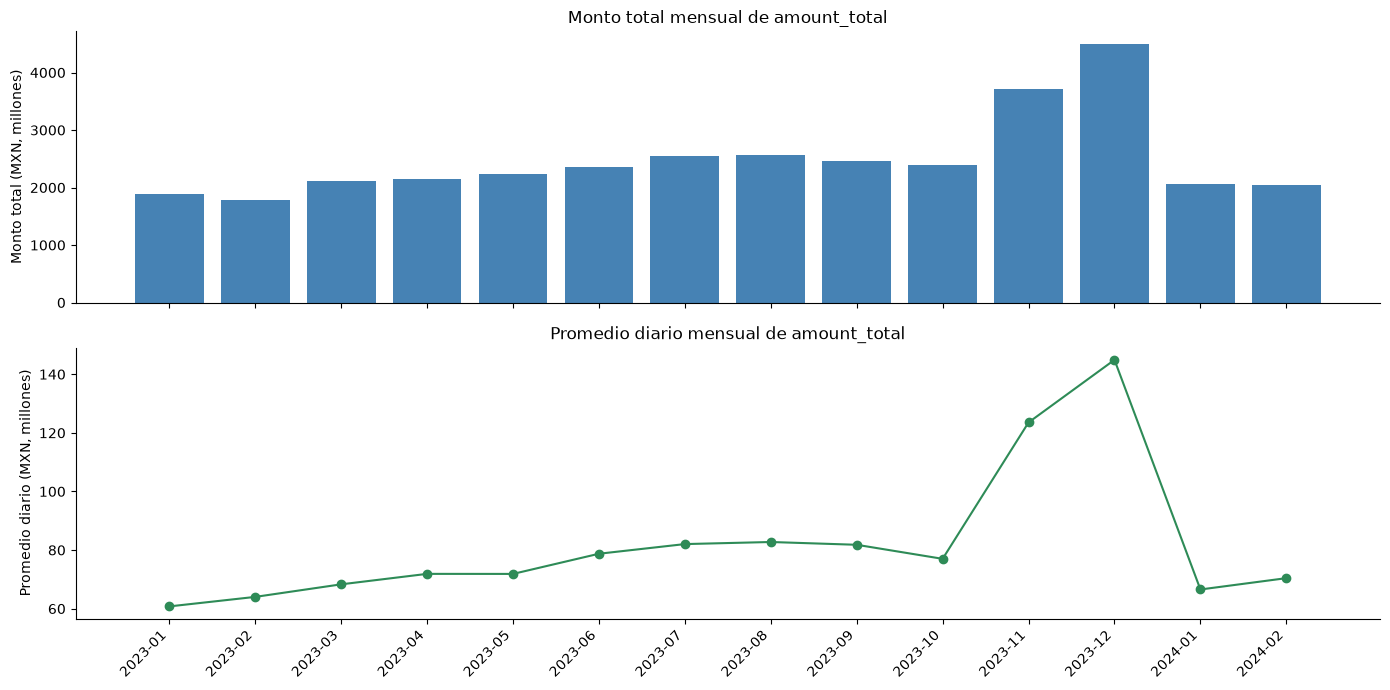

In [32]:
monthly_agg = (
    df.assign(mes=df["date_dt"].dt.to_period("M"))
    .groupby("mes")
    .agg(
        monto_total_mensual=("amount_total", "sum"),
        numero_registros=("amount_total", "count"),
    )
    .reset_index()
)
monthly_agg["promedio_diario_mensual"] = (
    monthly_agg["monto_total_mensual"]
    / monthly_agg["mes"].apply(lambda p: p.days_in_month)
)
monthly_agg["promedio_por_registro"] = (
    monthly_agg["monto_total_mensual"] / monthly_agg["numero_registros"]
)

print("Resumen mensual de amount_total:")
print(monthly_agg.set_index("mes").round(2).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

x = range(len(monthly_agg))
axes[0].bar(x, monthly_agg["monto_total_mensual"] / 1e6, color="steelblue", edgecolor="none")
axes[0].set_ylabel("Monto total (MXN, millones)")
axes[0].set_title("Monto total mensual de amount_total")

axes[1].plot(x, monthly_agg["promedio_diario_mensual"] / 1e6, marker="o", lw=1.5, color="seagreen")
axes[1].set_ylabel("Promedio diario (MXN, millones)")
axes[1].set_title("Promedio diario mensual de amount_total")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([str(m) for m in monthly_agg["mes"]], rotation=45, ha="right")

plt.tight_layout()
plt.show()

La revisión mensual permite identificar picos comerciales (Buen Fin, temporada navideña, quincenas) y posibles cambios de tendencia a lo largo del periodo. La presencia de estos patrones de calendario sugiere que las variables de evento incluidas en el dataset (`is_buen_fin`, `is_navidad_season`, `is_payday`, etc.) son variables explicativas relevantes para el modelo.

La validación futura del modelo **debe ser temporal**: entrenar con meses anteriores y evaluar en meses posteriores, sin división aleatoria. Esto es esencial para evitar que información del futuro contamine el entrenamiento y para obtener métricas representativas del entorno de despliegue.

Con aproximadamente 14 meses de historia disponibles, los patrones estacionales pueden identificarse, pero la estacionalidad anual debe interpretarse con cautela dado que solo se dispone de un ciclo completo.

---

### Conclusión de viabilidad para pronóstico

Estos análisis adicionales apoyan la viabilidad de un problema de pronóstico de ventas y demanda comercial a nivel `date × store_id × category`:

- La variabilidad por serie muestra heterogeneidad entre tiendas y categorías: algunas combinaciones son más estables y otras más volátiles, lo cual es esperable en retail a este nivel de granularidad.
- El baseline naive con rezago de 7 días proporciona una referencia preliminar que permite evaluar la mejora de modelos posteriores.
- La revisión temporal confirma que `amount_total` presenta patrones de calendario y eventos que justifican una validación temporal estricta.

El pronóstico sigue siendo una formulación defendible para una primera solución. Debe interpretarse como **pronóstico de ventas o demanda comercial**, y no como una solución completa de reposición física de inventario — la reposición física depende de factores adicionales (stocks, tiempos de entrega, capacidad de almacén) que no están presentes en este dataset.

## 14. Definición del problema de negocio

Con base en los resultados del EDA, comparamos tres posibles formulaciones del problema:

---

### A. Pronóstico de demanda
**Problema:** Predecir `units_sold` o `amount_total` futuros al nivel `fecha × store_id × categoría`.

**Valor de negocio:** Impulsa decisiones de reabastecimiento, asignación de personal, planeación de inventario y programación de promociones.

**Evidencia del EDA:**
- `amount_total`: 0% faltantes, estructura temporal sólida — diferencias promedio observadas por día de semana (fines de semana +60%), `is_buen_fin` (+267%), `is_navidad_season` (+53%), `is_payday` (+37%), `is_semana_santa` (-46%)
- `avg_ticket` es prácticamente constante en todos los eventos temporales (~411 MXN) — las diferencias observadas son principalmente de volumen. Existen diferencias de ticket entre segmentos (Supercenter ~418 MXN, NSE A/B ~579 MXN vs C ~340 MXN), pero no son el factor temporal principal
- Heterogeneidad clara por formato de tienda y categoría (Supercenter 3.5x Express; Abarrotes 2.4x Cuidado_Personal)
- Gradiente de NSE pronunciado (A/B = 247K vs C = 139K) — las características de tienda son variables explicativas informativas
- La cobertura es prácticamente completa: 203,958 combinaciones observadas frente a 204,000 esperadas (42 faltantes) — limitación menor documentada
- `has_promotion` no muestra una diferencia promedio relevante en `amount_total` (variación entre -0.6% y +0.8%), pero sí se asocia con mayores conteos de transacciones (+22%). Por ello conviene conservarla como variable explicativa candidata e interpretar su importancia con cautela, sin asumir causalidad

---

### B. Priorización operativa / oportunidad de ventas
**Problema:** Clasificar combinaciones tienda-categoría por demanda esperada o presión operativa.

**Valor de negocio:** Permite a los gerentes de tienda priorizar acciones (reabastecimiento, asignación de personal) entre un gran número de combinaciones.

**Evidencia del EDA:**
- `replenishment_signal` tiene solo 0.47% de faltantes (concentrados en los dos primeros días del periodo — 1 y 2 de enero de 2023, no al final), y muestra una asociación alta con `total_transactions` (0.851) y `units_sold` (0.814)
- Varianza significativa entre formatos, regiones y categorías confirma una segmentación relevante
- Este problema es viable pero menos bien definido — no hay un objetivo de clasificación claro ni métrica de evaluación sin un KPI de negocio explícito

---

### C. Detección de anomalías
**Problema:** Identificar patrones inusuales en ventas, unidades, ticket o consistencia de datos.

**Valor de negocio:** Monitoreo operativo, alertas de calidad de datos, hipótesis de prevención de pérdidas.

**Evidencia del EDA:**
- La verificación de consistencia sugiere que el 19.96% de las filas (donde existen datos de efectivo) tienen `total_transactions ≠ cash + card`. Esto puede ser una señal de calidad de datos, aunque también podría reflejar otros métodos de pago no desglosados en el dataset
- La cobertura es prácticamente completa (203,958 de 204,000 combinaciones esperadas, 42 faltantes) — sin brechas estructurales mayores que detectar
- Menos directamente relacionado con una decisión de planeación de negocio en un entregable de 48 horas

## 15. Dirección recomendada

Con base en los hallazgos reales del EDA y en la validación adicional de viabilidad, la estrategia recomendada es:

---

**Pronóstico de ventas y demanda comercial al nivel `fecha × store_id × categoría`**

**Variable objetivo principal:** `amount_total`
- 0% de valores faltantes en `amount_total` — cobertura prácticamente completa (203,958 de 204,000 combinaciones, 42 faltantes; limitación menor documentada)
- Directamente relacionada con ingresos — mayor relevancia de negocio para la planeación retail
- Estructura temporal sólida y consistente observada en los datos: fines de semana (+60%), Buen Fin (+267%), Navidad (+53%), quincenas (+37%), Semana Santa (-46%)
- Las diferencias asociadas a eventos temporales parecen estar explicadas principalmente por volumen, más que por cambios fuertes en `avg_ticket` (`avg_ticket` ≈ 411 MXN prácticamente constante en eventos; diferencias entre segmentos y NSE existen pero son secundarias)

**Variable objetivo secundaria (opcional):** `units_sold`
- 3% faltantes — manejable pero requiere tratamiento
- Puede considerarse como variable objetivo alternativa o métrica complementaria; más interpretable operativamente para decisiones de reabastecimiento

**Variables explicativas clave confirmadas por el EDA:**
- Temporales: `day_of_week`, `is_weekend`, `month`, `week_of_year`
- Eventos retail mexicano: `is_buen_fin`, `is_navidad_season`, `is_payday`, `is_semana_santa`, `is_holiday`
- Características de tienda: `store_format`, `region`, `socioeconomic_level`, `size_sqm`
- Categoría: `category`
- `has_promotion` no muestra una diferencia promedio relevante en `amount_total`, pero sí se asocia con mayores conteos de transacciones. Conviene conservarla como variable explicativa candidata e interpretar su importancia con cautela, sin asumir causalidad

**Uso cauteloso de `replenishment_signal`**
`replenishment_signal` puede ser útil para entender presión operativa o para formular un problema alternativo de priorización. Sin embargo, dado que fue generada internamente con base en demanda observada (asociación alta con `total_transactions` = 0.851, con `units_sold` = 0.814), no debe usarse de forma ingenua como predictor directo en un modelo de pronóstico de demanda, porque podría introducir fuga de información (leakage). Sus nulos (0.47%) se concentran en los primeros dos días del periodo (1 y 2 de enero de 2023), no al final.

**¿Por qué no detección de anomalías?**
La brecha del 19.96% en la consistencia de transacciones es una señal operativa relevante, pero podría reflejar otros métodos de pago no registrados más que errores definitivos. Afecta a `cash_transactions`, no a `amount_total`. La detección de anomalías es más difícil de evaluar y está menos ligada a decisiones de planeación en un alcance de 48 horas.

---

> **Conclusión:** Proceder con pronóstico de ventas y demanda comercial sobre `amount_total` al grano `fecha × store_id × categoría`. Variables explicativas principales: características de tienda (`store_format`, `region`, `socioeconomic_level`), categoría, y señales de calendario (`day_of_week`, `is_weekend`, `is_buen_fin`, `is_navidad_season`, `is_payday`, `is_semana_santa`). `has_promotion` se mantiene como variable candidata con interpretación cautelosa. La validación debe ser temporal (entrenar con meses anteriores, evaluar en meses posteriores). La historia disponible de ~14 meses es suficiente para una primera solución, pero limita la afirmación de estacionalidad anual robusta. Esta solución no debe presentarse como una solución completa de reposición física de inventario. La cobertura es prácticamente completa (42 combinaciones faltantes de 204,000), lo cual no impide avanzar pero debe documentarse.